In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Load the Excel file
df = pd.read_csv("support_files/species_samples_report.csv", sep=';')
df

,species,validation samples,training samples,validation accuracy
0,lythrum_salicaria,12897,31920,0.4913
1,lythrum_alatum,10366,34451,0.9591
2,lythrum_hyssopifolia,9103,35714,0.3532
3,lythrum_junceum,2957,41860,0.5952
4,lythrum_portula,2287,42530,0.2545
5,lythrum_virgatum,2119,42698,0.9018
6,lythrum_californicum,2094,42723,0.9618
7,lythrum_lineare,445,44372,0.9865
8,lythrum_flagellare,336,44481,0.9613
9,lythrum_tribracteatum,326,44491,0.6442


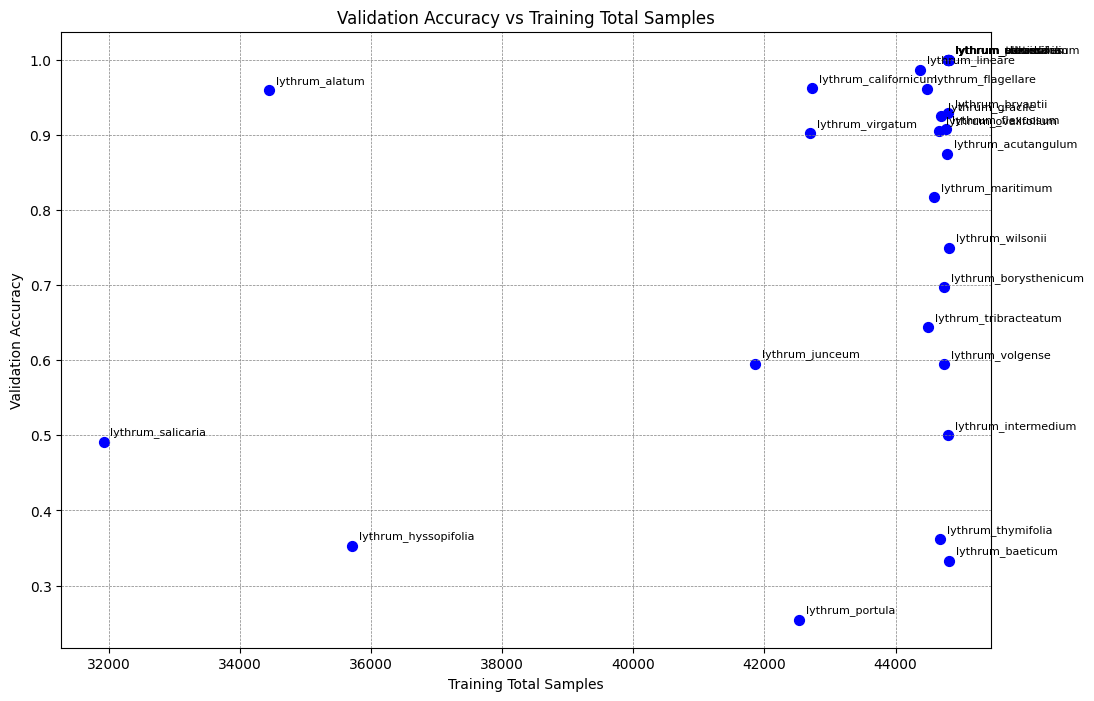

In [38]:
# Plot Training Total Samples vs Validation Accuracy
# Plot Training Total Samples vs Validation Accuracy with white background
plt.style.use('default')
plt.figure(figsize=(12,8))
plt.scatter(df["training samples"], df["validation accuracy"], s=50, color='blue')

# Annotate each point with species name
for i, row in df.iterrows():
    plt.annotate(row["species"], 
                 (row["training samples"], row["validation accuracy"]),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

plt.title("Validation Accuracy vs Training Total Samples")
plt.xlabel("Training Total Samples")
plt.ylabel("Validation Accuracy")
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.savefig(fname='support_files/accuracy_vs_training.pdf')

plt.show()




In [25]:
acc_mean = df['validation accuracy'].mean()
acc_std = df['validation accuracy'].std()

print(f'Average accuracy: {acc_mean}\n Accuracy Standard Deviation: {acc_std}')

Average accuracy: 0.7751642857142856
 Accuracy Standard Deviation: 0.24494997556460488


In [36]:
weighted_accuracy = (df['validation samples'] * df['validation accuracy']).sum() / df['validation samples'].sum()
float(weighted_accuracy)

0.6259989706920502

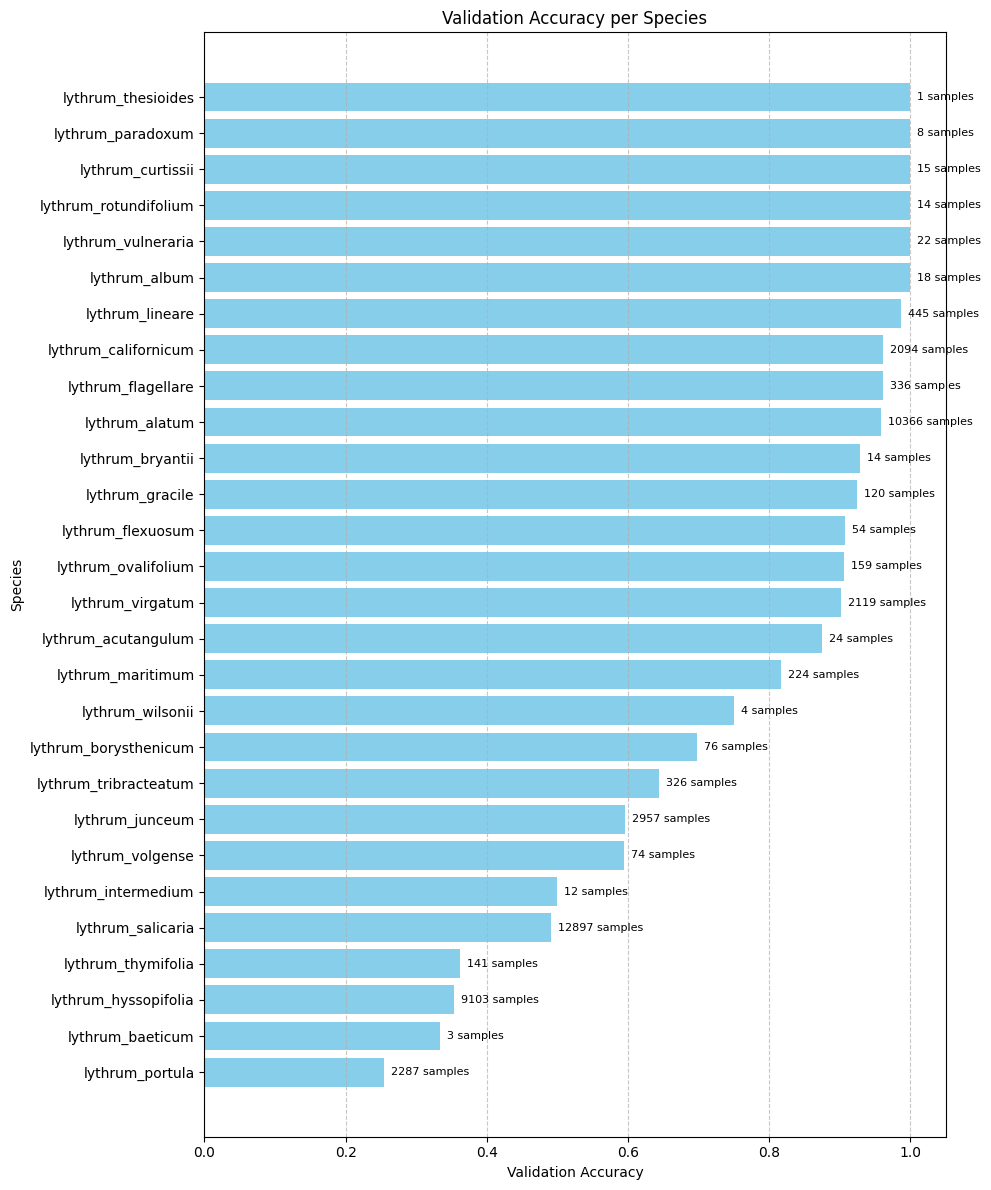

In [37]:
# Sort by validation accuracy
df_sorted = df.sort_values(by="validation accuracy", ascending=True)

plt.style.use('default')
plt.figure(figsize=(10,12))

# Plot horizontal bars
bars = plt.barh(range(len(df_sorted)), df_sorted["validation accuracy"], color='skyblue')

# Set y-ticks as species names
plt.yticks(range(len(df_sorted)), df_sorted["species"])

# Annotate validation samples consistently next to bars
for i, (acc, samples) in enumerate(zip(df_sorted["validation accuracy"], df_sorted["validation samples"])):
    plt.text(acc + 0.01, i, f"{samples} samples", va='center', fontsize=8)

plt.title("Validation Accuracy per Species")
plt.xlabel("Validation Accuracy")
plt.ylabel("Species")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('support_files/name_vs_accuracy.pdf')
plt.show()

